# CNN전이학습_data_augmentation
* 전이학습: 사전에 훈련된 모델을 가져와서 사용하는 것
* data_augmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈이터가 적어서 확보가 어려움, 비쌈, 기존 이미지 데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img

2025-05-22 18:33:09.917238: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-22 18:33:09.928302: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747906389.940694   18490 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747906389.944424   18490 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747906389.954088   18490 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
image = load_img("./catanddog/bird.jpg")
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

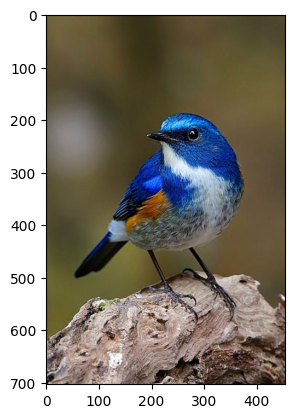

In [4]:
plt.imshow(image)
plt.show()

# Image Augmentation(이미지 증폭)

In [5]:
imggen = ImageDataGenerator(
            rescale= 1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode='nearest'
            )

In [6]:
image_array.shape

(703, 454, 3)

차원 늘리기

In [7]:
# image_array.reshape((1,) + image_array.shape).shape

In [8]:
image_array = image_array.reshape((1,) + image_array.shape)
image_array.shape

(1, 703, 454, 3)

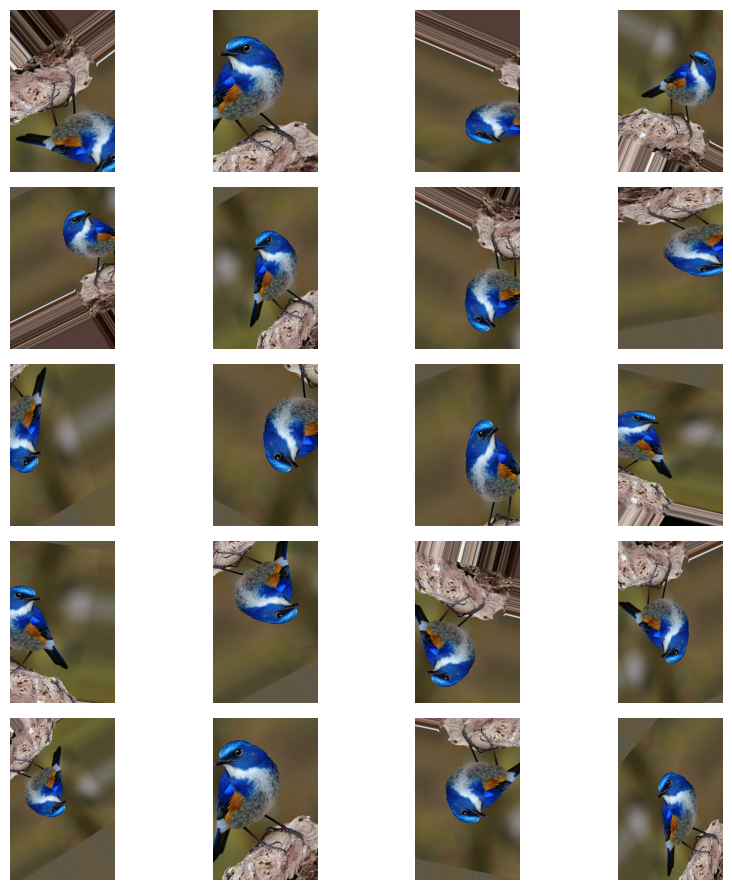

In [9]:
fig, axes = plt.subplots(5, 4, figsize=(9,9))
axes = axes.ravel()

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# image_augmentation을 이용한 개/고양이 분류모델 만들기

In [10]:
# 데이터 로드
train_dir = './catanddog/train/'
valid_dir = './catanddog/validation/'
batch_size = 16 # 한 번에 불러오는 사진의 개수, 분석 모델에 따라서 16(큼) ~ 32(작음) 사이로 지정
image_size = (224, 224) # 모델의 입력 크기에 맞춤

In [11]:
# 이미지 증강
train_aug = ImageDataGenerator(
            rescale=1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest')

valid_aug = ImageDataGenerator(rescale=1./255)

# 이미지 제너레이터
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)


X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [12]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [13]:
cnn_model = Sequential()
cnn_model.add(Input(shape=(224,224,3)))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(2, activation='softmax'))
cnn_model.summary()

I0000 00:00:1747906395.475152   18490 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,815,266 (10.74 MB)

 Trainable params: 2,815,266 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import tensorflow as tf

/home/fintech/miniforge3/envs/face/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000


I0000 00:00:1747906397.693206   18562 service.cc:152] XLA service 0x7f9710003220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747906397.693241   18562 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-22 18:33:17.721831: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747906397.936553   18562 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-22 18:33:18.450648: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[16,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0} %bitcast.4930, f32[32,3,3,3]{3,2,1,0} %bitcast.4937, f32[32]{0} %bitcast.5501), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBi

  2/139 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.2969 - loss: 0.7049

I0000 00:00:1747906404.057328   18562 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.4868 - loss: 0.6943

2025-05-22 18:34:24.671802: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[16,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0} %bitcast.555, f32[32,3,3,3]{3,2,1,0} %bitcast.562, f32[32]{0} %bitcast.564), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv2d_1/convolution" source_file="/home/fintech/miniforge3/envs/face/lib/python3.10/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-05-22 18:34:24.843445: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted poten


Epoch 1: val_loss improved from inf to 0.69159, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 463ms/step - accuracy: 0.4869 - loss: 0.6943 - val_accuracy: 0.5816 - val_loss: 0.6916
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.5273 - loss: 0.6924
Epoch 2: val_loss improved from 0.69159 to 0.68658, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 334ms/step - accuracy: 0.5273 - loss: 0.6924 - val_accuracy: 0.5816 - val_loss: 0.6866
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.5258 - loss: 0.6914
Epoch 3: val_loss improved from 0.68658 to 0.67155, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 40s 283ms/step - accuracy: 0.5257 - loss: 0.6914 - val_accuracy: 0.5510 - val_loss: 0.6716
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.5310 - loss: 0.6904
Epoch 4: val_loss improved from 0.67155 to 0.66156, saving model to ./model/cnn_catndog.ker

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.6688 - loss: 0.6173
Epoch 24: val_loss did not improve from 0.52159
139/139 ━━━━━━━━━━━━━━━━━━━━ 43s 305ms/step - accuracy: 0.6689 - loss: 0.6171 - val_accuracy: 0.5918 - val_loss: 0.6537
Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6679 - loss: 0.6090
Epoch 25: val_loss did not improve from 0.52159
139/139 ━━━━━━━━━━━━━━━━━━━━ 43s 308ms/step - accuracy: 0.6679 - loss: 0.6089 - val_accuracy: 0.7245 - val_loss: 0.5373
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.6837 - loss: 0.5977
Epoch 26: val_loss did not improve from 0.52159
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 299ms/step - accuracy: 0.6837 - loss: 0.5976 - val_accuracy: 0.6939 - val_loss: 0.5672
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.6709 - loss: 0.6030
Epoch 27: val_loss did not improve from 0.52159
139/139 ━━━━━━━━━━━━━━━━━━━━ 42s 304ms/step - accuracy: 0.6710 - loss: 0.6029 - val_accuracy: 0.75

139/139 ━━━━━━━━━━━━━━━━━━━━ 41s 292ms/step - accuracy: 0.7245 - loss: 0.5447 - val_accuracy: 0.7245 - val_loss: 0.4947
Epoch 49/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.7063 - loss: 0.5538
Epoch 49: val_loss did not improve from 0.47834
139/139 ━━━━━━━━━━━━━━━━━━━━ 39s 278ms/step - accuracy: 0.7063 - loss: 0.5537 - val_accuracy: 0.6939 - val_loss: 0.5642
Epoch 50/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.7239 - loss: 0.5505
Epoch 50: val_loss did not improve from 0.47834
139/139 ━━━━━━━━━━━━━━━━━━━━ 38s 272ms/step - accuracy: 0.7240 - loss: 0.5504 - val_accuracy: 0.6939 - val_loss: 0.5153
Epoch 51/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.7351 - loss: 0.5206
Epoch 51: val_loss did not improve from 0.47834
139/139 ━━━━━━━━━━━━━━━━━━━━ 39s 276ms/step - accuracy: 0.7351 - loss: 0.5207 - val_accuracy: 0.7857 - val_loss: 0.4927
Epoch 52/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.7351 - loss: 0.5284
Epoch 52: va

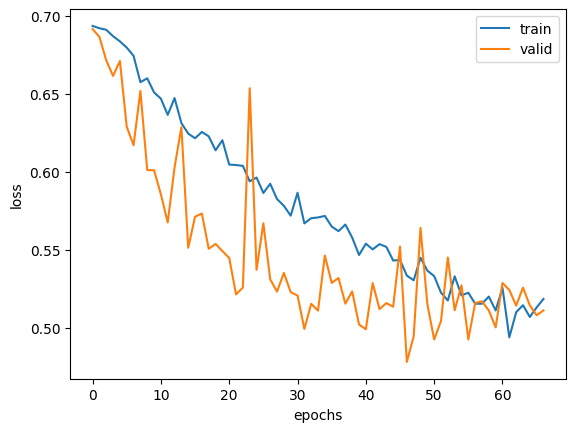

In [15]:
cnn_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/cnn_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
cnn_history = cnn_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [16]:
class_indices = valid_gen.class_indices
class_indices

{'Cat': 0, 'Dog': 1}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step


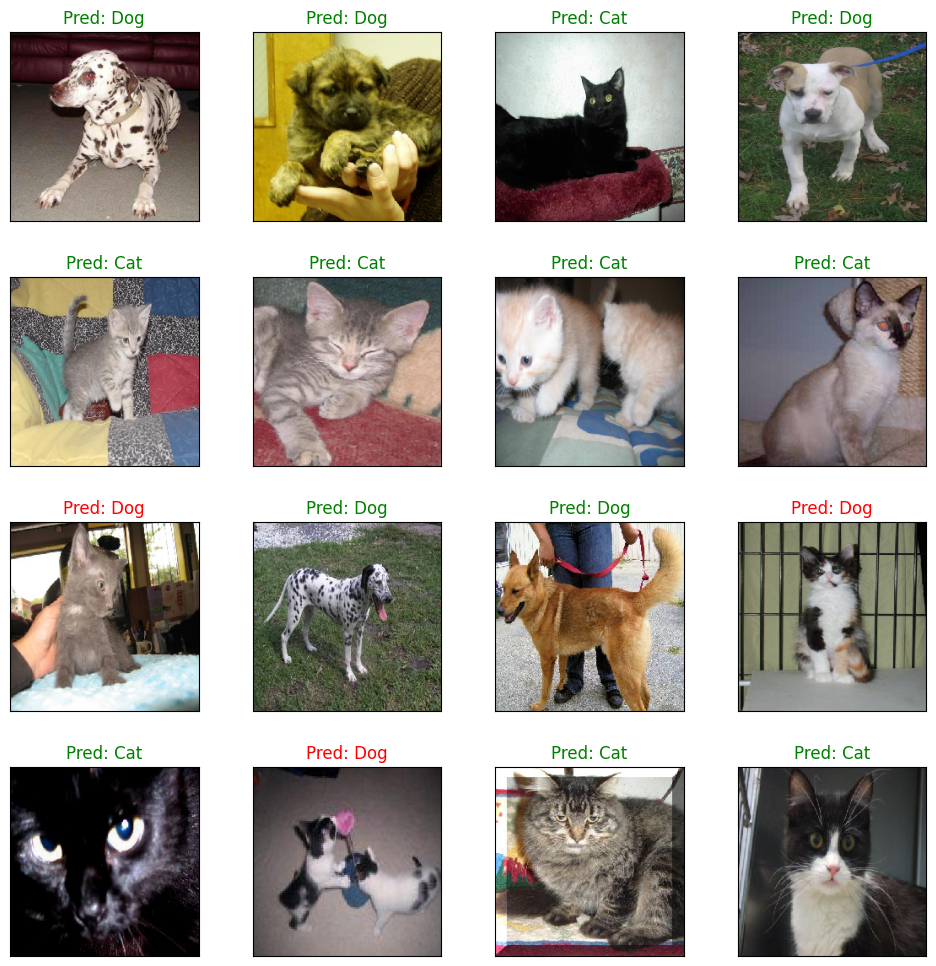


cnn_best_model평가 결과: Loss: 0.3940, Accuracy: 0.8125


In [17]:
# best 모델 로드
cnn_best_model = load_model("./model/cnn_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = cnn_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# 전이학습
* 사전에 훈련된 모델을 가지고 새로운 데이터를 넣어서 튜닝을 하거나 결과를 출력
* keras.applications에 있음

# ResNet50
* ResNet50에 사용할 경우, rescale=1./255는 제거하고 preprocessing_function=preprocess_input을 사용
* keras의 ResNet50은 입력 이미지를 BGR로 바꾸고 채널별 평균을 빼는 전처리를 필요로 하기 때문

In [18]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2
from tensorflow.keras.applications.resnet import preprocess_input
import tensorflow as tf

In [19]:
# ✅ ResNet50에 맞는 이미지 증강기 (rescale 제거 → preprocess_input 사용)
train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✔️ ResNet 전용 전처리
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.2,
    shear_range=0.6,
    zoom_range=0.3,
    fill_mode='nearest'
)

valid_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input  # ✔️ Validation도 동일하게 처리
)

# ✅ 이미지 제너레이터 생성
train_gen = train_aug.flow_from_directory(
    train_dir,
    target_size=image_size,  # 예: (224, 224)
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

valid_gen = valid_aug.flow_from_directory(
    valid_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# ✅ 배치 확인
X_batch, y_batch = next(train_gen)
print(X_batch.shape)  # 예: (32, 224, 224, 3)
print(y_batch.shape)
print(train_gen.class_indices)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [20]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [21]:
# base_model.summary()

In [22]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8808 - loss: 0.2893
Epoch 1: val_loss improved from inf to 0.12835, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 44s 278ms/step - accuracy: 0.8809 - loss: 0.2890 - val_accuracy: 0.9592 - val_loss: 0.1283
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9263 - loss: 0.1941
Epoch 2: val_loss improved from 0.12835 to 0.10298, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 58s 417ms/step - accuracy: 0.9264 - loss: 0.1940 - val_accuracy: 0.9694 - val_loss: 0.1030
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9381 - loss: 0.1740
Epoch 3: val_loss improved from 0.10298 to 0.09529, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 446ms/step - accuracy: 0.9381 - loss: 0.1738 - val_accuracy: 0.9796 - val_loss: 0.0953
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9482 - loss: 0.1

139/139 ━━━━━━━━━━━━━━━━━━━━ 76s 547ms/step - accuracy: 0.9726 - loss: 0.0733 - val_accuracy: 0.9898 - val_loss: 0.0603
Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9817 - loss: 0.0701
Epoch 25: val_loss improved from 0.06028 to 0.05885, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 75s 534ms/step - accuracy: 0.9816 - loss: 0.0702 - val_accuracy: 0.9898 - val_loss: 0.0588
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.9672 - loss: 0.0843
Epoch 26: val_loss did not improve from 0.05885
139/139 ━━━━━━━━━━━━━━━━━━━━ 73s 522ms/step - accuracy: 0.9672 - loss: 0.0844 - val_accuracy: 0.9898 - val_loss: 0.0612
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.9696 - loss: 0.0838
Epoch 27: val_loss did not improve from 0.05885
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 517ms/step - accuracy: 0.9695 - loss: 0.0838 - val_accuracy: 0.9898 - val_loss: 0.0639
Epoch 28/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/st

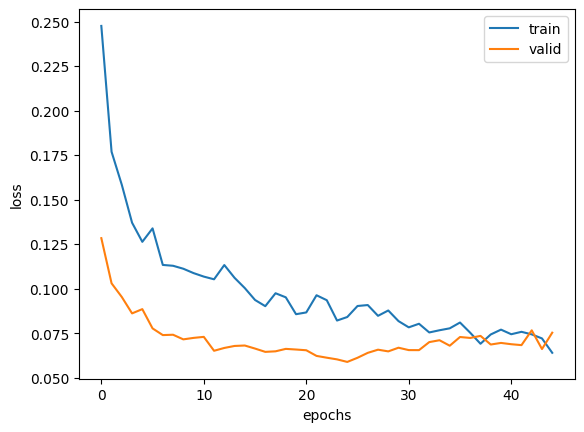

In [24]:
res50_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res50_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res50_history = res50_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [26]:
from sklearn.metrics import accuracy_score

7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step 

[전체 Validation Accuracy] 0.5612
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


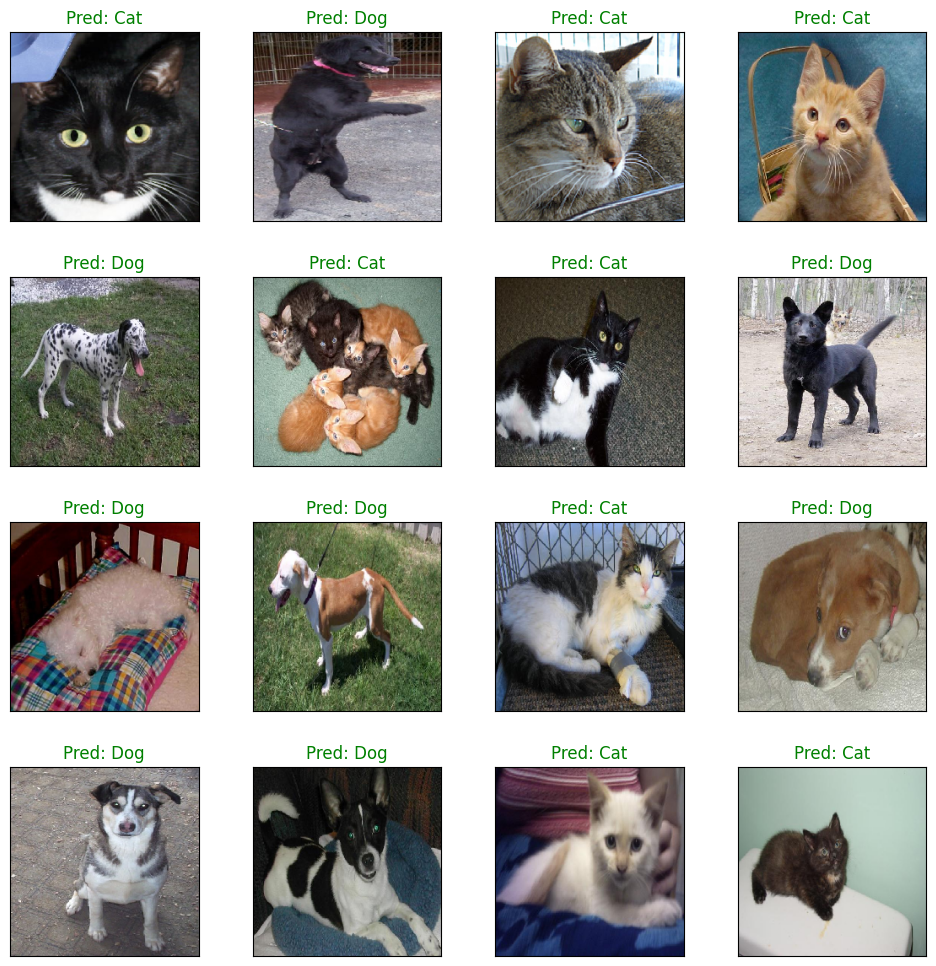

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 763ms/step - accuracy: 0.9900 - loss: 0.0567

[모델 평가 결과] Loss: 0.0588, Accuracy: 0.9898


In [27]:
# ✅ 모델 로드
res50_best_model = load_model("./model/res50_catndog.keras")

# ✅ 클래스 이름 추출
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# ✅ 전체 validation 데이터로 예측
cnn_pred = res50_best_model.predict(valid_gen, verbose=1)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = valid_gen.classes  # 전체 정답

# ✅ 정확도 출력
acc = accuracy_score(true_values, pred_values)
print(f"\n[전체 Validation Accuracy] {acc:.4f}")

# ✅ 시각화용: 소량 배치만 가져오기
sample_batch, label_batch = next(valid_gen)
sample_pred = res50_best_model.predict(sample_batch)
sample_pred_values = np.argmax(sample_pred, axis=1)
sample_true_values = np.argmax(label_batch, axis=1)

# ✅ 시각화: 이미지 복구 후 출력
def deprocess_input(x):
    """ResNet의 preprocess_input을 반대로 적용 (BGR→RGB + 평균값 복원)"""
    x = x.copy()
    # ImageNet 평균값 (BGR 순)
    mean = [103.939, 116.779, 123.68]
    x[..., 0] += mean[0]  # B
    x[..., 1] += mean[1]  # G
    x[..., 2] += mean[2]  # R
    x = x[..., ::-1]  # BGR → RGB
    return np.clip(x / 255.0, 0, 1)  # matplotlib은 0~1 사이값을 기대함

# ✅ 이미지 시각화
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0.3)
num_images = min(16, sample_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    img = deprocess_input(sample_batch[i])
    ax.imshow(img)
    pred_label = class_names[sample_pred_values[i]]
    true_label = class_names[sample_true_values[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# ✅ 전체 평가
loss, acc = res50_best_model.evaluate(valid_gen, verbose=1)
print(f"\n[모델 평가 결과] Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# ResNet152V2

In [28]:
base_model2 = ResNet152V2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='avg'
)

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [29]:
base_model2.summary()

Model: "resnet152v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 58,331,648 (222.52 MB)

 Trainable params: 58,187,904 (221.97 MB)

 Non-trainable params: 143,744 (561.50 KB)

In [30]:
base_model2.trainable = False
res152v2_model = Sequential()
res152v2_model.add(base_model2)
res152v2_model.add(Dense(2, activation="softmax"))

Epoch 1/1000


2025-05-22 20:31:47.910296: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.11GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-22 20:31:55.531395: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.16GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-22 20:32:00.998814: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.14GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-22 20:32:03.684595: W external/local_xla/xla/ts

 41/139 ━━━━━━━━━━━━━━━━━━━━ 2:08 1s/step - accuracy: 0.4622 - loss: 82.0095

2025-05-22 20:33:16.206330: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.11GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-22 20:33:23.799834: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.16GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-05-22 20:33:29.335268: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.14GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4799 - loss: 49.3378
Epoch 1: val_loss improved from inf to 18.40208, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.4800 - loss: 49.1823 - val_accuracy: 0.4694 - val_loss: 18.4021
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4833 - loss: 12.9754
Epoch 2: val_loss improved from 18.40208 to 13.53896, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.4834 - loss: 12.9740 - val_accuracy: 0.4796 - val_loss: 13.5390
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5327 - loss: 12.0045
Epoch 3: val_loss did not improve from 13.53896
139/139 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.5327 - loss: 12.0067 - val_accuracy: 0.5102 - val_loss: 14.2817
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5124 - loss: 11.2332
Epoch 4: val_loss improved from 13.53896 to 11.00360, sa

139/139 ━━━━━━━━━━━━━━━━━━━━ 98s 706ms/step - accuracy: 0.5343 - loss: 6.0124 - val_accuracy: 0.5510 - val_loss: 4.2215
Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.5350 - loss: 5.5440
Epoch 25: val_loss improved from 4.14355 to 4.04796, saving model to ./model/res152v2_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 110s 789ms/step - accuracy: 0.5350 - loss: 5.5464 - val_accuracy: 0.6122 - val_loss: 4.0480
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5318 - loss: 5.5647
Epoch 26: val_loss did not improve from 4.04796
139/139 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.5317 - loss: 5.5683 - val_accuracy: 0.5102 - val_loss: 7.1890
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.5409 - loss: 5.2488
Epoch 27: val_loss did not improve from 4.04796
139/139 ━━━━━━━━━━━━━━━━━━━━ 126s 905ms/step - accuracy: 0.5408 - loss: 5.2491 - val_accuracy: 0.5612 - val_loss: 4.3484
Epoch 28/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/st

Epoch 49/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.5413 - loss: 6.0468
Epoch 49: val_loss did not improve from 2.84922
139/139 ━━━━━━━━━━━━━━━━━━━━ 87s 621ms/step - accuracy: 0.5412 - loss: 6.0457 - val_accuracy: 0.6633 - val_loss: 2.9308
Epoch 50/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.5471 - loss: 4.6721
Epoch 50: val_loss did not improve from 2.84922
139/139 ━━━━━━━━━━━━━━━━━━━━ 86s 617ms/step - accuracy: 0.5470 - loss: 4.6765 - val_accuracy: 0.5714 - val_loss: 4.2606
Epoch 51/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.5240 - loss: 4.7939
Epoch 51: val_loss did not improve from 2.84922
139/139 ━━━━━━━━━━━━━━━━━━━━ 86s 619ms/step - accuracy: 0.5240 - loss: 4.7998 - val_accuracy: 0.5102 - val_loss: 8.5098
Epoch 52/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.5247 - loss: 6.9169
Epoch 52: val_loss did not improve from 2.84922
139/139 ━━━━━━━━━━━━━━━━━━━━ 87s 625ms/step - accuracy: 0.5248 - loss: 6.9065 - val_

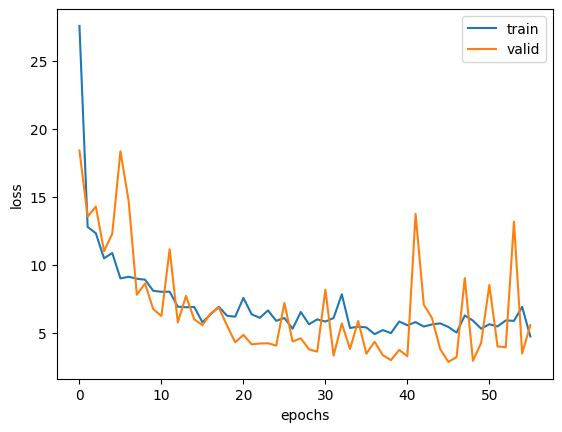

In [31]:
res152v2_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res152v2_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
res152v2_history = res152v2_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(res152v2_history.history['loss'])
plt.plot(res152v2_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [ ]:
# best 모델 로드
res152v2_best_model = load_model("./model/res152v2_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = res152v2_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = res152v2_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres152v2_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# convnextbase로 분석하기

In [33]:
from tensorflow.keras.applications import ConvNeXtBase

In [34]:
# 이미지 증강
train_aug2 = ImageDataGenerator(
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest',
            dtype='float32')

valid_aug2 = ImageDataGenerator(dtype='float32')

# 이미지 제너레이터
train_gen2 = train_aug2.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)

valid_gen2 = valid_aug2.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42)


X_batch2, y_batch2 = next(train_gen2)
print(X_batch2.shape)
print(y_batch2.shape)
print(train_gen2.class_indices)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


In [35]:
base_model3 = ConvNeXtBase(
    include_top=False,
    include_preprocessing=True,
    weights="imagenet",
    input_shape=(224,224,3),
    pooling='avg',
    classes=1000,
    classifier_activation="softmax",
    name="convnext_base",
)

350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [36]:
base_model3.trainable = False
ConvNeXtBase_model = Sequential()
ConvNeXtBase_model.add(base_model3)
ConvNeXtBase_model.add(Dense(2, activation="softmax"))

In [ ]:
ConvNeXtBase_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/ConvNeXtBase_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
ConvNeXtBase_history = ConvNeXtBase_model.fit(train_gen2, epochs=1000, validation_data=valid_gen2,
                           callbacks=[early_stop, check_point])
plt.plot(ConvNeXtBase_history.history['loss'])
plt.plot(ConvNeXtBase_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score

In [ ]:
# Best 모델 로드
ConvNeXtBase_best_model = load_model("./model/ConvNeXtBase_catndog.keras")

# 클래스 이름 추출
class_indices = valid_gen2.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]

# ✅ [1] 전체 validation dataset으로 예측 및 정확도 계산
cnn_pred = ConvNeXtBase_best_model.predict(valid_gen2, verbose=1)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = valid_gen2.classes  # 전체 validation 레이블

# 정확도 출력
acc = accuracy_score(true_values, pred_values)
print(f"\n[전체 Validation Accuracy] {acc:.4f}")

# ✅ [2] 소량 배치만 시각화용으로 가져오기
small_batch, label_batch = next(valid_gen2)
small_pred = ConvNeXtBase_best_model.predict(small_batch)
small_pred_values = np.argmax(small_pred, axis=1)
small_true_values = np.argmax(label_batch, axis=1)

# ✅ 시각화 (최대 16장)
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0.3)
num_images = min(16, small_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])
    ax.imshow(small_batch[i].astype("uint8"))  # ConvNeXt는 0~255 이미지 입력
    pred_label = class_names[small_pred_values[i]]
    true_label = class_names[small_true_values[i]]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# ✅ [3] 전체 validation 데이터로 loss, accuracy 평가
loss, acc = ConvNeXtBase_best_model.evaluate(valid_gen2, verbose=1)
print(f"\n[모델 평가 결과] Loss: {loss:.4f}, Accuracy: {acc:.4f}")